In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [ ]:
# Main Dataset
sales_df = pd.read_csv("train.csv", encoding="latin1")

# Secondary Dataset
vg_df = pd.read_csv("vgsales.csv")

print("Sales Dataset Shape :", sales_df.shape)
print("Video Game Dataset Shape :", vg_df.shape)

Sales Dataset Shape : (9800, 18)
Video Game Dataset Shape : (16598, 11)


In [ ]:
sales_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [ ]:
sales_df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


In [ ]:
sales_df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
sales_df = sales_df.drop_duplicates()

In [ ]:
sales_df["Order Date"] = pd.to_datetime(sales_df["Order Date"], format='%d/%m/%Y')
sales_df["Ship Date"] = pd.to_datetime(sales_df["Ship Date"], format='%d/%m/%Y')

In [ ]:
sales_df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [ ]:
sales_df["Year"] = sales_df["Order Date"].dt.year
sales_df["Month"] = sales_df["Order Date"].dt.month
sales_df["Month Name"] = sales_df["Order Date"].dt.month_name()
sales_df["Quarter"] = sales_df["Order Date"].dt.quarter
sales_df["Week"] = sales_df["Order Date"].dt.isocalendar().week
sales_df["Day"] = sales_df["Order Date"].dt.day_name()

In [ ]:
def season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Summer"
    elif month in [6,7,8]:
        return "Monsoon"
    else:
        return "Autumn"

sales_df["Season"] = sales_df["Month"].apply(season)

In [ ]:
sales_df["Shipping Days"] = (
    sales_df["Ship Date"] -
    sales_df["Order Date"]
).dt.days

In [ ]:
weekly_sales = sales_df.groupby(
    pd.Grouper(key="Order Date", freq="W")
)["Sales"].sum().reset_index()

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [ ]:
monthly_sales = sales_df.groupby(
    pd.Grouper(key="Order Date", freq="M")
)["Sales"].sum().reset_index()

monthly_sales.head()

/tmp/ipykernel_637/1855849391.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key="Order Date", freq="M")


,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [ ]:
category_sales = (
    sales_df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


In [ ]:
region_year_sales = sales_df.groupby(
    ["Region","Year"]
)["Sales"].sum().reset_index()

region_year_sales

,Region,Year,Sales
0,Central,2015,102920.5206
1,Central,2016,102425.1724
2,Central,2017,145673.8800
3,Central,2018,141627.3402
4,East,2015,127652.8190
5,East,2016,153225.1830
6,East,2017,178511.5380
7,East,2018,210129.1860
8,South,2015,103374.9055
9,South,2016,70076.0825


In [ ]:
sales_df.groupby("Region")["Shipping Days"].mean()

,Shipping Days
Region,
Central,4.065876
East,3.910233
South,3.961202
West,3.930255


In [ ]:
monthly_pattern = sales_df.groupby(
    ["Year","Month"]
)["Sales"].sum().reset_index()

monthly_pattern

,Year,Month,Sales
0,2015,1,14205.7070
1,2015,2,4519.8920
2,2015,3,55205.7970
3,2015,4,27906.8550
4,2015,5,23644.3030
5,2015,6,34322.9356
6,2015,7,33781.5430
7,2015,8,27117.5365
8,2015,9,81623.5268
9,2015,10,31453.3930


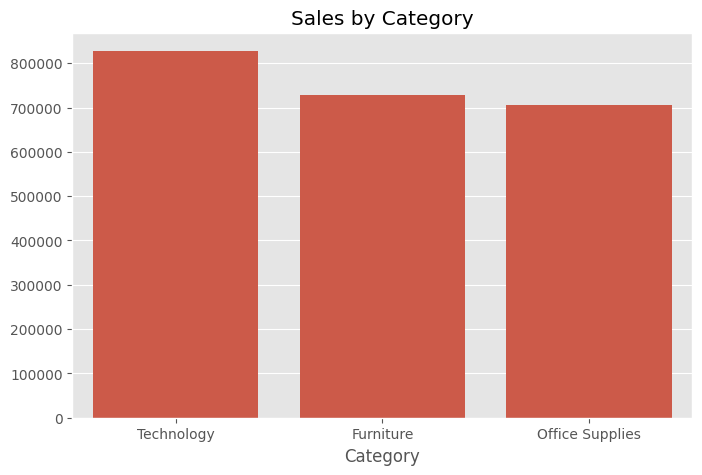

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)
plt.title("Sales by Category")
plt.show()

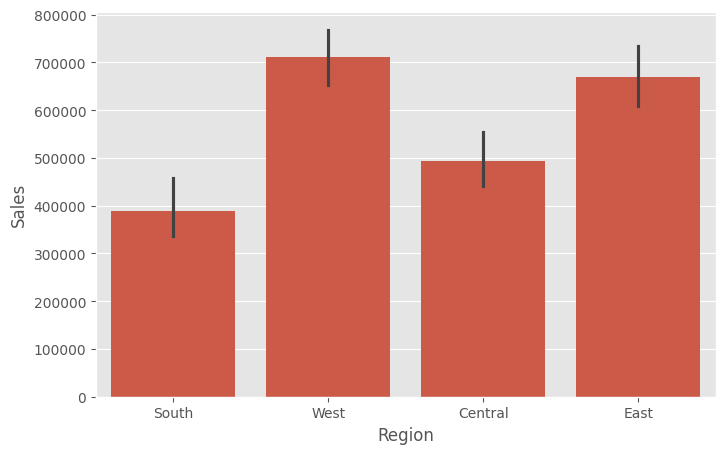

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=sales_df,
    x="Region",
    y="Sales",
    estimator=sum
)
plt.show()

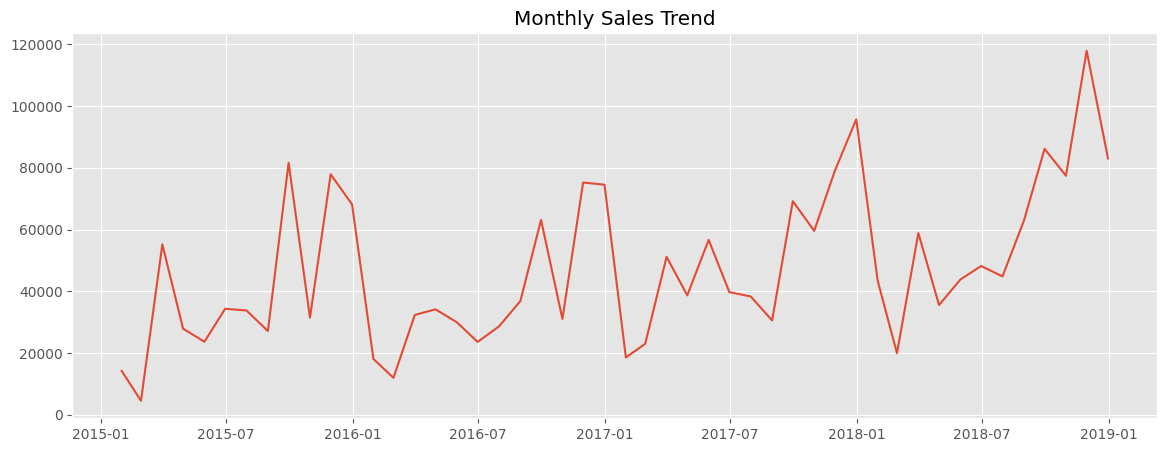

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"]
)
plt.title("Monthly Sales Trend")
plt.show()

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import matplotlib.pyplot as plt

In [ ]:
monthly_sales = (
    sales_df
    .groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
    .sum()
)

monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


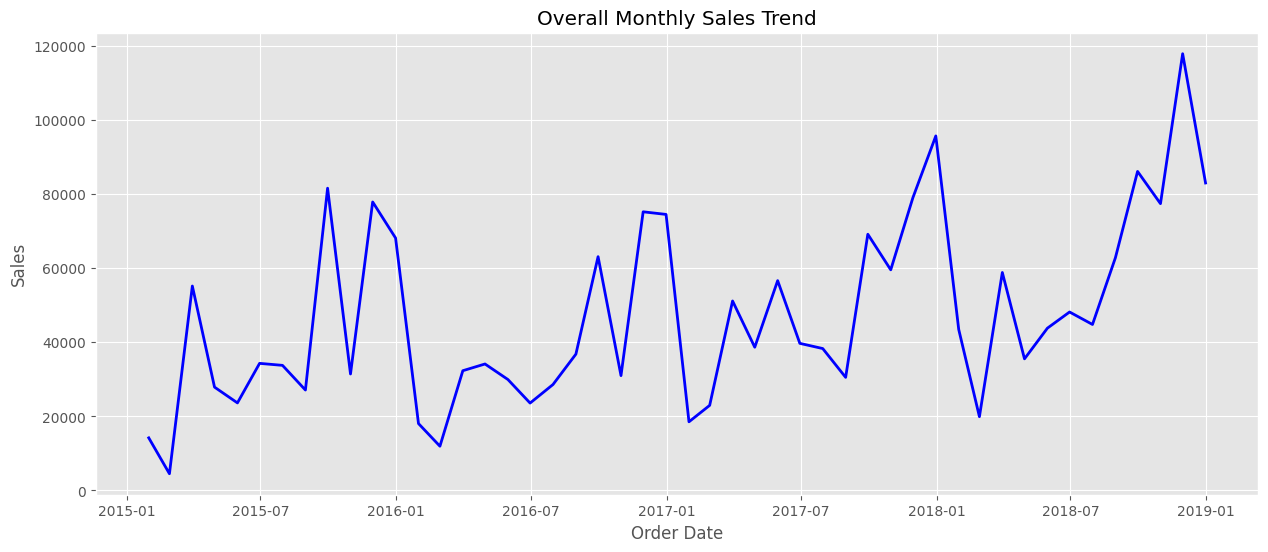

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(monthly_sales,
         color="blue",
         linewidth=2)

plt.title("Overall Monthly Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

In [ ]:
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

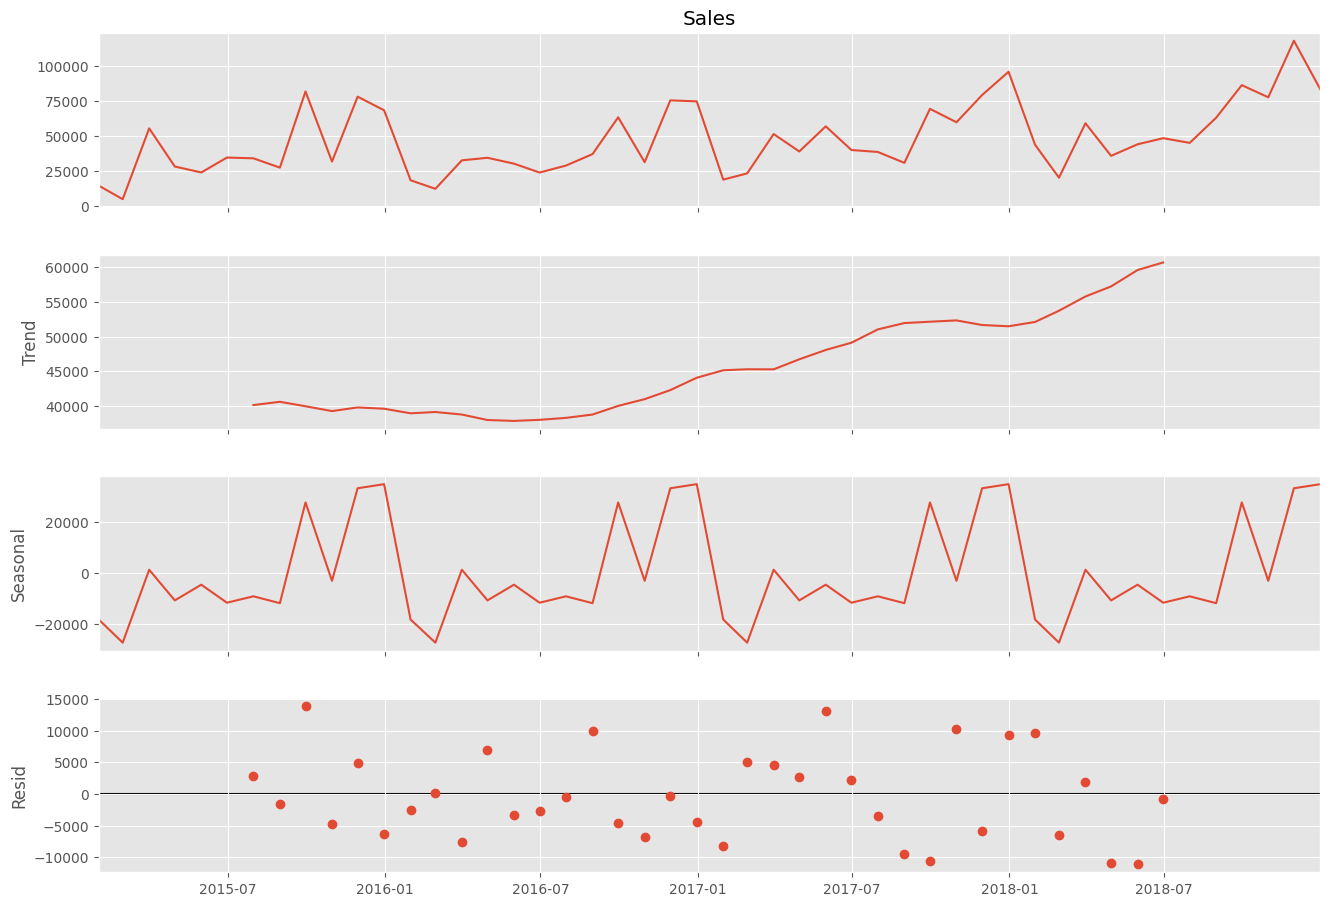

In [ ]:
fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.show()

In [ ]:
result = adfuller(monthly_sales)

print("ADF Statistic :", result[0])
print("P-value :", result[1])
print()

print("Critical Values")

for key,value in result[4].items():
    print(key,":",value)

ADF Statistic : -4.416136761430769
P-value : 0.00027791039276670623

Critical Values
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


In [ ]:
if result[1] < 0.05:
    print("The time series is Stationary")
else:
    print("The time series is Non-Stationary")

The time series is Stationary


In [ ]:
monthly_diff = monthly_sales.diff().dropna()

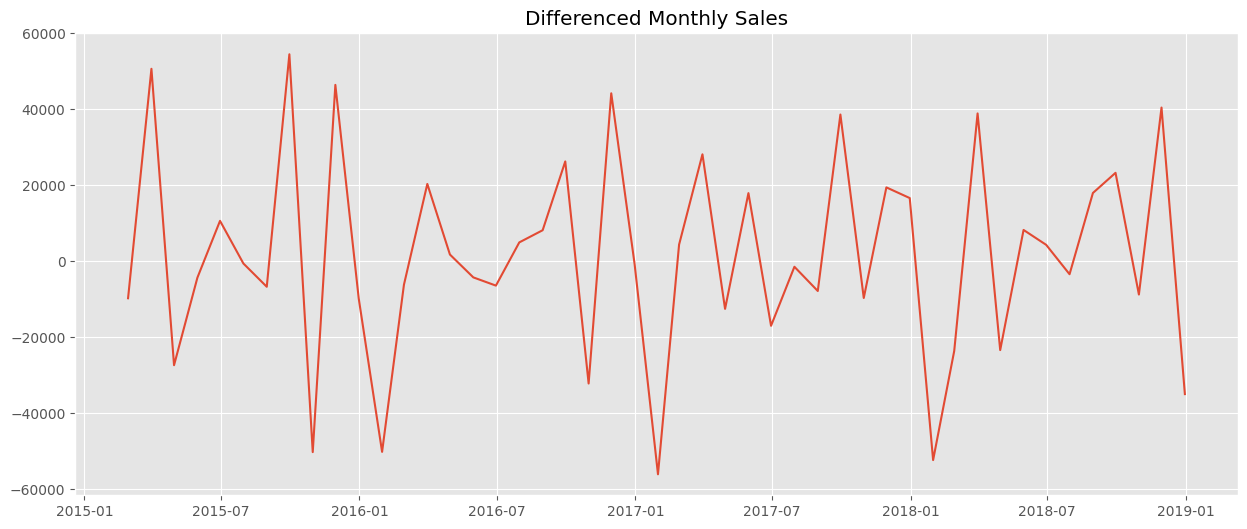

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(monthly_diff)

plt.title("Differenced Monthly Sales")

plt.grid(True)

plt.show()

In [ ]:
result2 = adfuller(monthly_diff)

print("ADF Statistic :", result2[0])
print("P-value :", result2[1])

for key,value in result2[4].items():
    print(key,":",value)

ADF Statistic : -8.727061830353268
P-value : 3.2669175472796045e-14
1% : -3.626651907578875
5% : -2.9459512825788754
10% : -2.6116707716049383


In [ ]:
if result2[1] < 0.05:
    print("Now the series is Stationary")
else:
    print("Still Non-Stationary")

Now the series is Stationary


In [ ]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import matplotlib.pyplot as plt

In [ ]:
monthly_sales = (
    sales_df
    .groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
    .sum()
)

monthly_sales = monthly_sales.asfreq("ME")

In [ ]:
train = monthly_sales[:-3]
test = monthly_sales[-3:]

In [ ]:
pip install statsmodels

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
sarima = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_model = sarima.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [ ]:
sarima_pred = sarima_model.forecast(3)

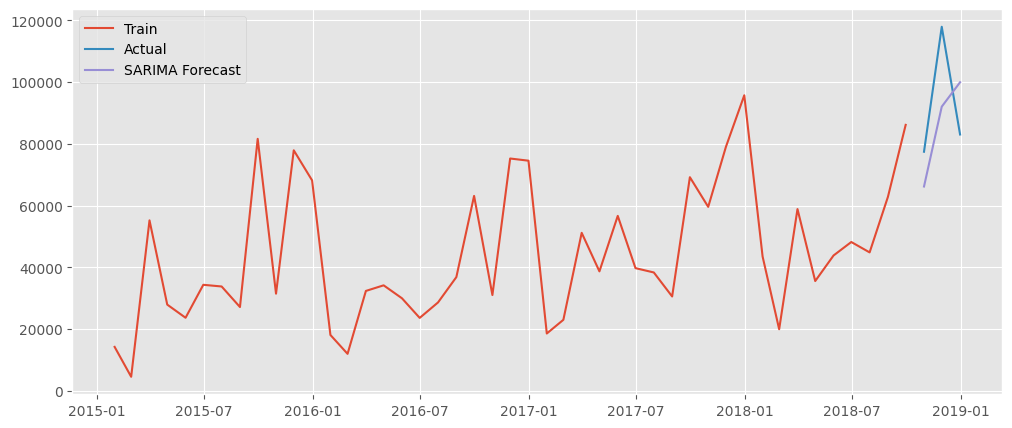

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, sarima_pred, label="SARIMA Forecast")

plt.legend()
plt.show()

In [ ]:
sarima_mae = mean_absolute_error(test, sarima_pred)

sarima_rmse = np.sqrt(
    mean_squared_error(test, sarima_pred)
)

sarima_mape = mean_absolute_percentage_error(
    test,
    sarima_pred
)

print(sarima_mae)
print(sarima_rmse)
print(sarima_mape)

18031.40467222437
19009.18206635205
0.18966498068433016


In [ ]:
pip install prophet

In [ ]:
from prophet import Prophet

In [ ]:
prophet_df = monthly_sales.reset_index()

prophet_df.columns = ["ds","y"]

In [ ]:
train_prophet = prophet_df[:-3]

test_prophet = prophet_df[-3:]

In [ ]:
model = Prophet()

model.fit(train_prophet)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = model.make_future_dataframe(
    periods=3,
    freq="ME"
)

forecast = model.predict(future)

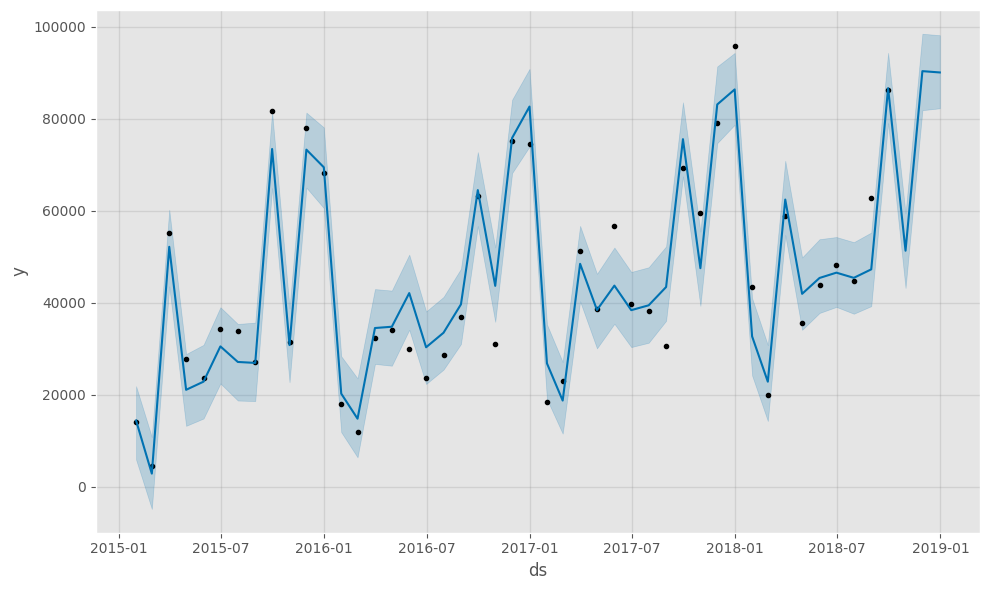

In [ ]:
model.plot(forecast)

plt.show()

In [ ]:
prophet_pred = forecast["yhat"].tail(3).values

In [ ]:
prophet_mae = mean_absolute_error(
    test_prophet["y"],
    prophet_pred
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        test_prophet["y"],
        prophet_pred
    )
)

prophet_mape = mean_absolute_percentage_error(
    test_prophet["y"],
    prophet_pred
)

In [ ]:
pip install xgboost

In [ ]:
from xgboost import XGBRegressor

In [ ]:
df_ml = monthly_sales.to_frame()

df_ml["Lag1"] = df_ml["Sales"].shift(1)
df_ml["Lag2"] = df_ml["Sales"].shift(2)
df_ml["Lag3"] = df_ml["Sales"].shift(3)

df_ml["RollingMean"] = (
    df_ml["Sales"]
    .rolling(3)
    .mean()
)

df_ml["Month"] = df_ml.index.month
df_ml["Quarter"] = df_ml.index.quarter

df_ml = df_ml.dropna()

In [ ]:
X = df_ml.drop("Sales", axis=1)

y = df_ml["Sales"]

In [ ]:
X_train = X[:-3]

X_test = X[-3:]

y_train = y[:-3]

y_test = y[-3:]

In [ ]:
xgb = XGBRegressor(
    n_estimators=200,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb.predict(X_test)

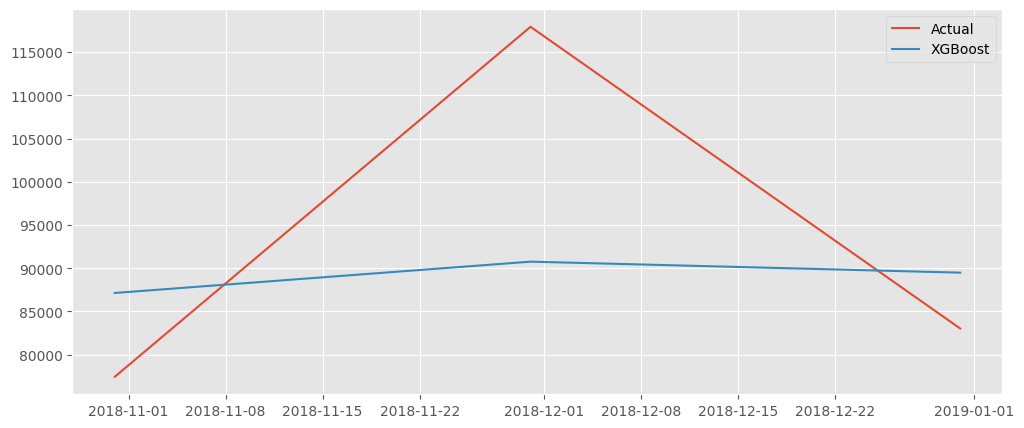

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(y_test.index,
         y_test,
         label="Actual")

plt.plot(y_test.index,
         xgb_pred,
         label="XGBoost")

plt.legend()

plt.show()

In [ ]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

xgb_mape = mean_absolute_percentage_error(
    y_test,
    xgb_pred
)

In [ ]:
comparison = pd.DataFrame({

"Model":[
    "SARIMA",
    "Prophet",
    "XGBoost"
],

"MAE":[
    sarima_mae,
    prophet_mae,
    xgb_mae
],

"RMSE":[
    sarima_rmse,
    prophet_rmse,
    xgb_rmse
],

"MAPE":[
    sarima_mape,
    prophet_mape,
    xgb_mape
]

})

comparison

,Model,MAE,RMSE,MAPE
0,SARIMA,18031.404672,19009.182066,0.189665
1,Prophet,20250.794428,22318.411366,0.218646
2,XGBoost,14443.456458,17069.090751,0.144473


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def monthly_sales_by_filter(df, column, value):
    filtered = df[df[column] == value]

    monthly = (
        filtered
        .groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
        .sum()
    )

    return monthly

In [ ]:
furniture = monthly_sales_by_filter(
    sales_df,
    "Category",
    "Furniture"
)

technology = monthly_sales_by_filter(
    sales_df,
    "Category",
    "Technology"
)

office = monthly_sales_by_filter(
    sales_df,
    "Category",
    "Office Supplies"
)

west = monthly_sales_by_filter(
    sales_df,
    "Region",
    "West"
)

east = monthly_sales_by_filter(
    sales_df,
    "Region",
    "East"
)

In [ ]:
def create_features(series):

    df = series.to_frame(name="Sales")

    df["Lag1"] = df["Sales"].shift(1)
    df["Lag2"] = df["Sales"].shift(2)
    df["Lag3"] = df["Sales"].shift(3)

    df["RollingMean"] = (
        df["Sales"]
        .rolling(3)
        .mean()
    )

    df["Month"] = df.index.month
    df["Quarter"] = df.index.quarter

    return df.dropna()

In [ ]:
def forecast_xgb(series):

    df = create_features(series)

    X = df.drop("Sales", axis=1)
    y = df["Sales"]

    model = XGBRegressor(
        n_estimators=200,
        random_state=42
    )

    model.fit(X, y)

    future = X.iloc[-1:]

    pred = model.predict(future)

    return pred[0]

In [ ]:
forecast_furniture = forecast_xgb(furniture)

forecast_technology = forecast_xgb(technology)

forecast_office = forecast_xgb(office)

forecast_west = forecast_xgb(west)

forecast_east = forecast_xgb(east)

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def sarima_forecast(series):

    model = SARIMAX(
        series,
        order=(1,1,1),
        seasonal_order=(1,1,1,12)
    )

    fit = model.fit(disp=False)

    return fit.forecast(3)

In [ ]:
forecast_furniture = sarima_forecast(furniture)

forecast_technology = sarima_forecast(technology)

forecast_office = sarima_forecast(office)

forecast_west = sarima_forecast(west)

forecast_east = sarima_forecast(east)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for va

In [ ]:
from prophet import Prophet

def prophet_forecast(series):

    df = series.reset_index()

    df.columns = ["ds","y"]

    model = Prophet()

    model.fit(df)

    future = model.make_future_dataframe(
        periods=3,
        freq="ME"
    )

    forecast = model.predict(future)

    return forecast.tail(3)

In [ ]:
forecast_furniture = prophet_forecast(furniture)

forecast_technology = prophet_forecast(technology)

forecast_office = prophet_forecast(office)

forecast_west = prophet_forecast(west)

forecast_east = prophet_forecast(east)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to overr

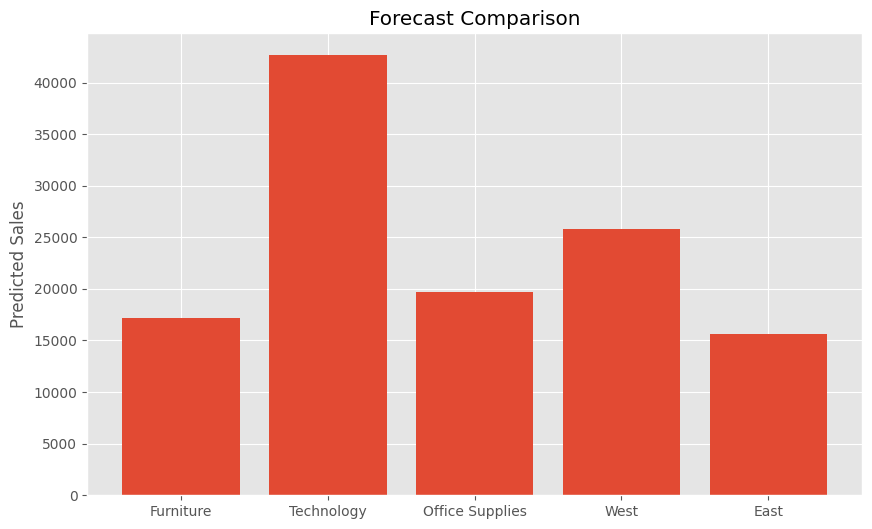

In [ ]:
forecast_df = pd.DataFrame({

"Segment":[
    "Furniture",
    "Technology",
    "Office Supplies",
    "West",
    "East"
],

"Forecast":[
    forecast_furniture["yhat"].iloc[-1],
    forecast_technology["yhat"].iloc[-1],
    forecast_office["yhat"].iloc[-1],
    forecast_west["yhat"].iloc[-1],
    forecast_east["yhat"].iloc[-1]
]

})

plt.figure(figsize=(10,6))

plt.bar(
    forecast_df["Segment"],
    forecast_df["Forecast"]
)

plt.title("Forecast Comparison")

plt.ylabel("Predicted Sales")

plt.show()

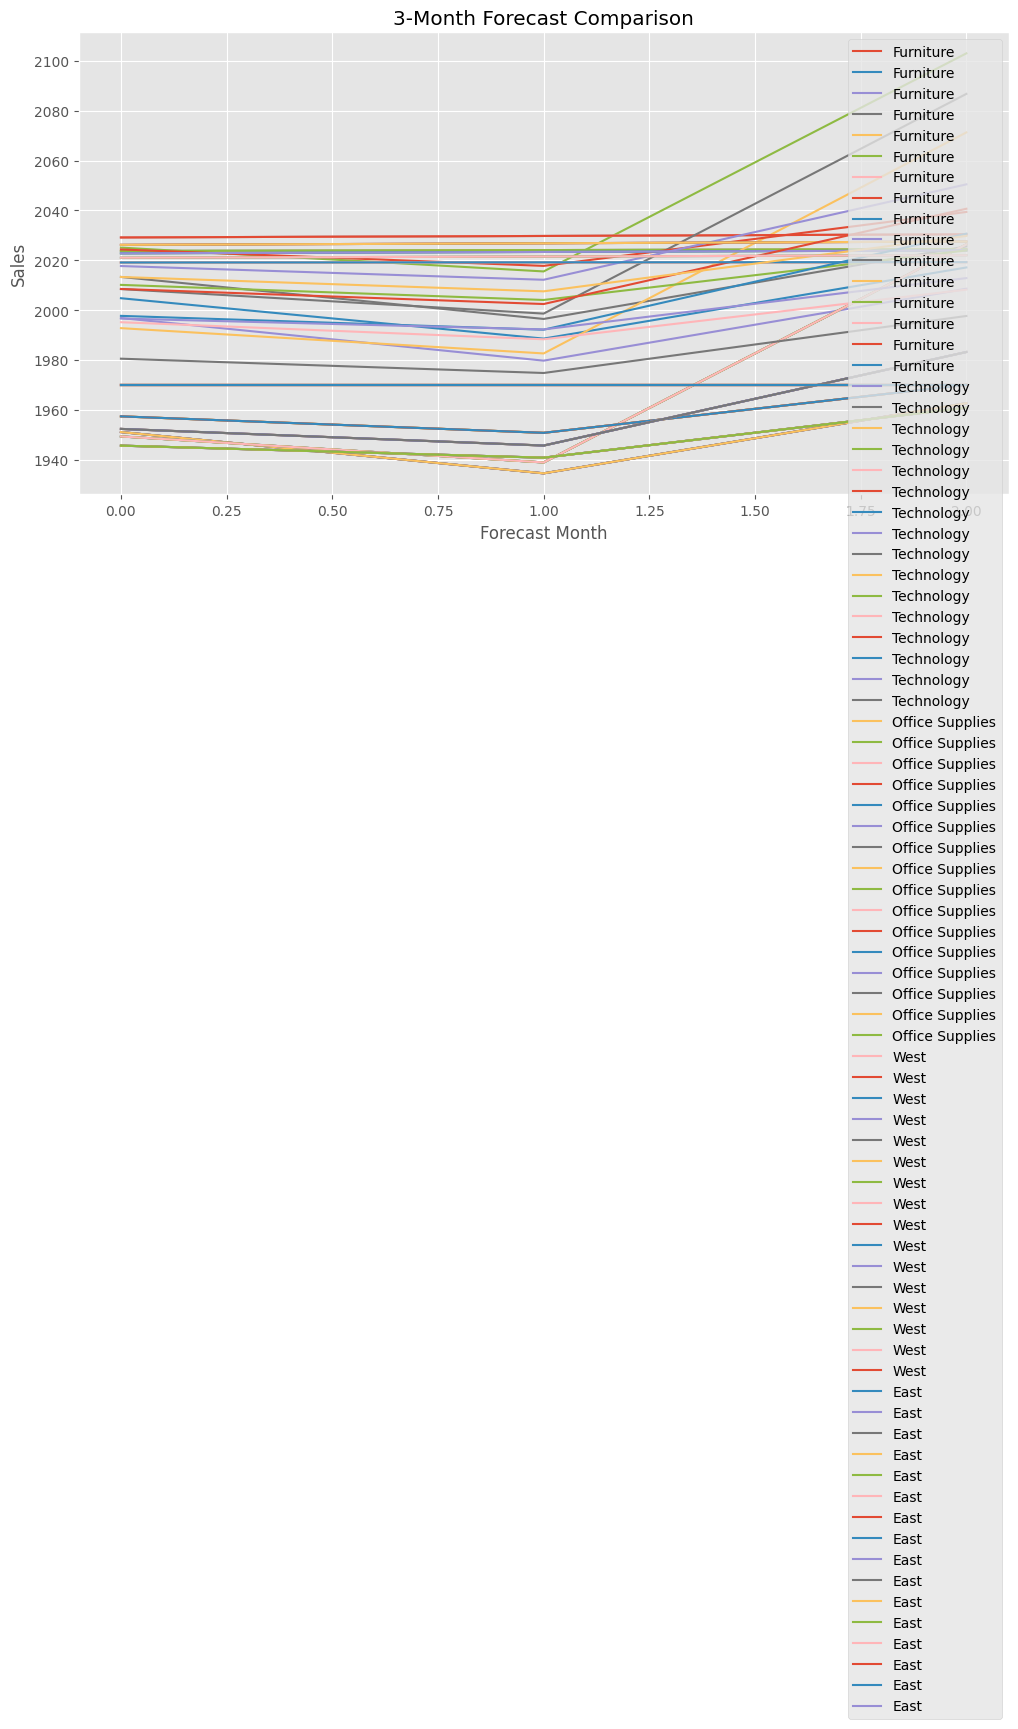

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(forecast_furniture.values, label="Furniture")

plt.plot(forecast_technology.values, label="Technology")

plt.plot(forecast_office.values, label="Office Supplies")

plt.plot(forecast_west.values, label="West")

plt.plot(forecast_east.values, label="East")

plt.legend()

plt.title("3-Month Forecast Comparison")

plt.xlabel("Forecast Month")

plt.ylabel("Sales")

plt.show()

In [ ]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
weekly_sales = (
    sales_df
    .groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [ ]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Anomaly"] = iso.fit_predict(
    weekly_sales[["Sales"]]
)

In [ ]:
anomalies = weekly_sales[
    weekly_sales["Anomaly"] == -1
]

anomalies

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


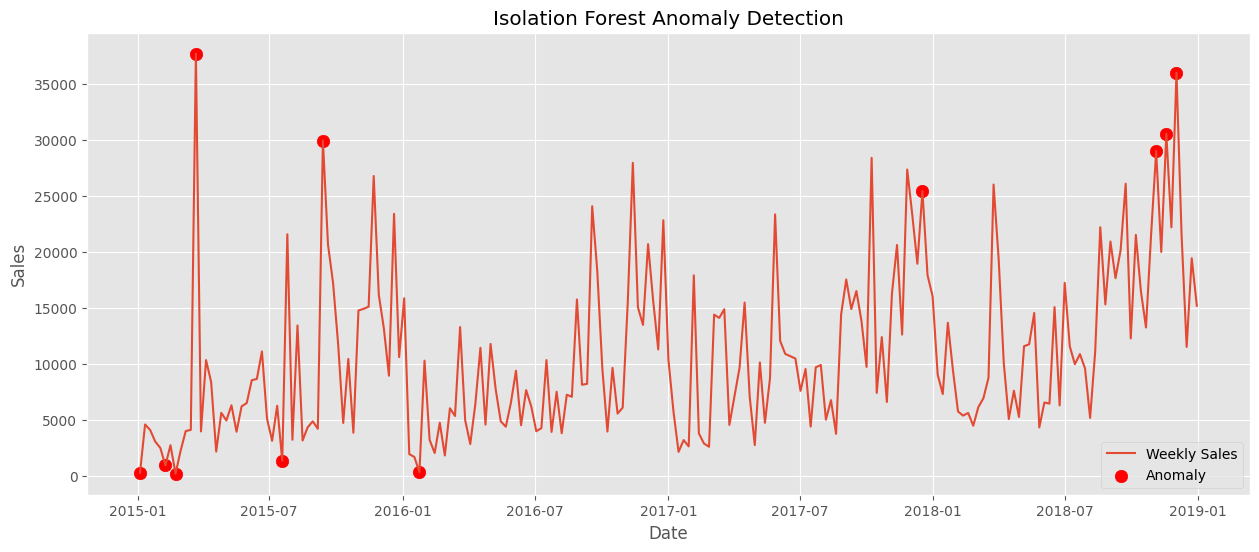

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    s=80,
    label="Anomaly"
)

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
weekly_sales["Rolling Mean"] = (
    weekly_sales["Sales"]
    .rolling(4)
    .mean()
)

weekly_sales["Rolling Std"] = (
    weekly_sales["Sales"]
    .rolling(4)
    .std()
)

weekly_sales["ZScore"] = (
    weekly_sales["Sales"] -
    weekly_sales["Rolling Mean"]
) / weekly_sales["Rolling Std"]

In [ ]:
z_anomalies = weekly_sales[
    abs(weekly_sales["ZScore"]) > 2
]

z_anomalies

,Order Date,Sales,Anomaly,Rolling Mean,Rolling Std,ZScore


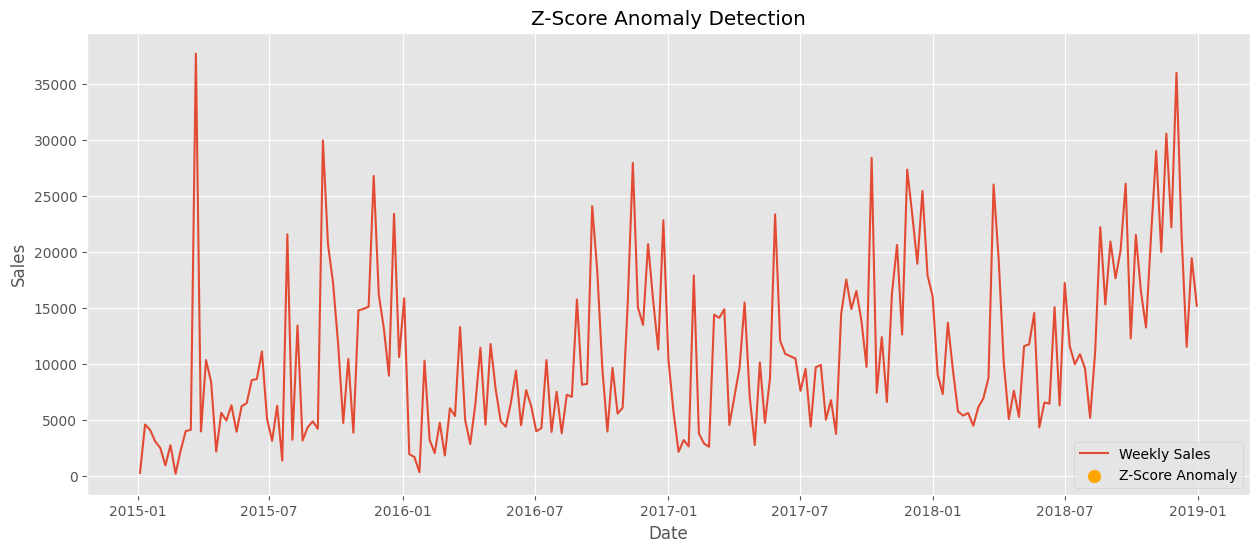

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    z_anomalies["Order Date"],
    z_anomalies["Sales"],
    color="orange",
    s=80,
    label="Z-Score Anomaly"
)

plt.title("Z-Score Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
print("Isolation Forest Anomalies :", len(anomalies))

print("Z-Score Anomalies :", len(z_anomalies))

Isolation Forest Anomalies : 11
Z-Score Anomalies : 0


In [ ]:
print("Isolation Forest")

display(anomalies)

print("Z-Score")

display(z_anomalies)

Isolation Forest


,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


Z-Score


,Order Date,Sales,Anomaly,Rolling Mean,Rolling Std,ZScore


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
product_df = sales_df.groupby("Sub-Category").agg(
    Total_Sales=("Sales", "sum"),
    Average_Order_Value=("Sales", "mean"),
    Sales_Volatility=("Sales", "std")
).reset_index()

In [ ]:
yearly_sales = sales_df.groupby(
    ["Sub-Category", "Year"]
)["Sales"].sum().reset_index()

growth = yearly_sales.groupby("Sub-Category")["Sales"].pct_change()

yearly_sales["Growth"] = growth

In [ ]:
growth_df = yearly_sales.groupby("Sub-Category")["Growth"].mean().reset_index()

growth_df.rename(
    columns={"Growth": "Sales_Growth"},
    inplace=True
)

In [ ]:
product_df = product_df.merge(
    growth_df,
    on="Sub-Category",
    how="left"
)

product_df.fillna(0, inplace=True)

product_df.head()

,Sub-Category,Total_Sales,Average_Order_Value,Sales_Volatility,Sales_Growth
0,Accessories,164186.7000,217.178175,337.723800,0.376381
1,Appliances,104618.4030,227.926804,378.006735,0.399276
2,Art,26705.4100,34.019631,60.301752,0.166056
3,Binders,200028.7850,134.067550,568.099970,0.218736
4,Bookcases,113813.1987,503.598224,641.419280,0.238065


In [ ]:
features = product_df.drop(
    "Sub-Category",
    axis=1
)

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [ ]:
wcss = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    wcss.append(model.inertia_)

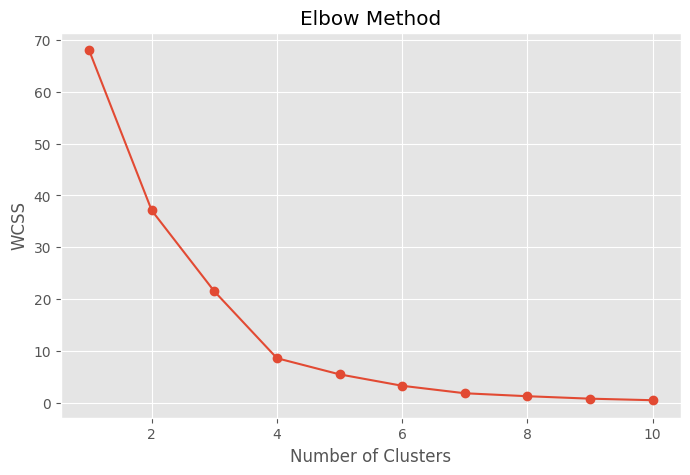

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

product_df["Cluster"] = kmeans.fit_predict(
    scaled_features
)

In [ ]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(
    scaled_features
)

product_df["PCA1"] = pca_features[:,0]

product_df["PCA2"] = pca_features[:,1]

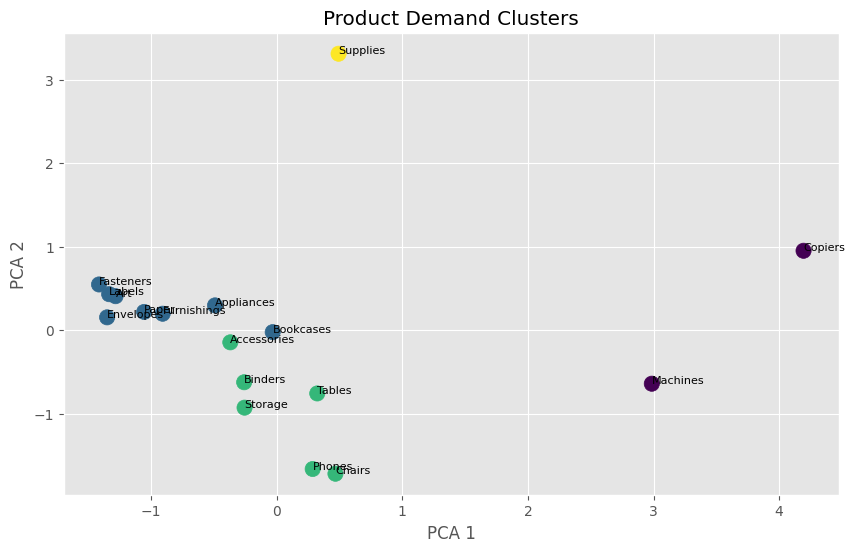

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    product_df["PCA1"],
    product_df["PCA2"],
    c=product_df["Cluster"],
    s=120
)

for i in range(len(product_df)):
    plt.text(
        product_df["PCA1"][i],
        product_df["PCA2"][i],
        product_df["Sub-Category"][i],
        fontsize=8
    )

plt.title("Product Demand Clusters")

plt.xlabel("PCA 1")

plt.ylabel("PCA 2")

plt.show()

In [ ]:
product_df[
    ["Sub-Category",
     "Cluster"]
].sort_values("Cluster")

,Sub-Category,Cluster
6,Copiers,0
11,Machines,0
4,Bookcases,1
1,Appliances,1
7,Envelopes,1
9,Furnishings,1
8,Fasteners,1
2,Art,1
12,Paper,1
10,Labels,1


In [ ]:
cluster_names = {

0:"High Volume, Stable Demand",

1:"Growing Demand",

2:"Low Volume, High Volatility",

3:"Declining Demand"

}

product_df["Cluster Name"] = product_df[
    "Cluster"
].map(cluster_names)

product_df[
    ["Sub-Category",
     "Cluster Name"]
]

,Sub-Category,Cluster Name
0,Accessories,"Low Volume, High Volatility"
1,Appliances,Growing Demand
2,Art,Growing Demand
3,Binders,"Low Volume, High Volatility"
4,Bookcases,Growing Demand
5,Chairs,"Low Volume, High Volatility"
6,Copiers,"High Volume, Stable Demand"
7,Envelopes,Growing Demand
8,Fasteners,Growing Demand
9,Furnishings,Growing Demand
